# ShinyGWASPheWAS — two-way Manhattan & PheWAS visualization (Yassue et al. 2022/2023)

**Paper:** Yassue RM, Galli G, Chen C-P J, Fritsche-Neto R, Morota G. *Genome-wide association analysis of hyperspectral reflectance data to dissect growth-related traits genetic architecture in maize under inoculation with plant growth-promoting bacteria.* bioRxiv 2022, doi:[10.1101/2022.08.11.503682](https://doi.org/10.1101/2022.08.11.503682); journal version Plant Direct 2023, doi:[10.1002/pld3.492](https://doi.org/10.1002/pld3.492)

**Author code:** [vt-ads/ShinyGWASPheWAS](https://github.com/vt-ads/ShinyGWASPheWAS) @ commit `d2523731d183c60f64e52d3534d7755d919bcbb1` (`app.R`)

## Purpose & exact scope
This notebook reproduces the paper's **interactive multi-phenotype GWAS visualization** (the Shiny app's two scientific panels) **headlessly**:
1. **Two-way Manhattan plot** — GWAS results for 13,826 SNPs, 3 manually measured traits (PH, SD, SDM) × 2 PGPB managements (B+, B−), plotted from the author-bundled `Manhatan_full.csv`.
2. **PheWAS plot** — GWAS summary of 281 hyperspectral phenotypes + 3 manual phenotypes for 10 SNPs, plotted from `PheWAS.csv`.

The ggplot2 pipelines are **exact copies** of the server code in `app.R` (lines 172–198 and 211–218) with the app's default widget values (point size 0.25, PIP y-label, threshold line at 1). The interactive `ggplotly()` layer and Shiny UI are omitted (headless adaptation); the same ggplot objects are saved as PNG. One additional adaptation: the app's unseeded `sample()` is seeded for reproducibility. **This visualization-only demo does not rerun the GWA analyses** (raw genotype/phenotype/hyperspectral data were not published).

**日本語:** このノートブックは、論文の著者らが公開した Shiny アプリ `ShinyGWASPheWAS`（コミット `d252373`）のサーバ側 ggplot2 コードをそのまま(headless)に実行し、two-way Manhattan 図と PheWAS 図を再現します。Shiny の対話 UI と ggplotly は省略され、同一の ggplot オブジェクトを PNG 保存します。GWA 解析自体の再実行は対象外です（生データは未公開）。


## Runtime selection

**Use a CPU runtime** (Runtime → Change runtime type → CPU). The workload is R tabulation/plotting of ≤5.5 MB CSV files; the author code has no GPU path, and no GPU is needed or recommended.

**Run all** executes end-to-end in a fresh runtime: R package install (~2–5 min) + downloads (~5.7 MB) + plotting (seconds).

**日本語:** CPU ランタイムを使用してください（GPU 不要）。全セル実行で 5〜10 分程度です。


In [ ]:
# Check the R interpreter that Colab's CPU image provides.
# Python here is only the launcher; all scientific computation runs in R.
import shutil, subprocess
rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
print("Rscript:", rscript)
res = subprocess.run([rscript, "--version"], capture_output=True, text=True, timeout=120)
print(res.stdout.strip() or res.stderr.strip())

Rscript: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)


Install the single R package the copied code needs (`ggplot2`). The full Shiny UI stack is intentionally not installed — the headless pipeline does not use it. **日本語:** 必要な R パッケージは ggplot2 のみです。

In [ ]:
# Install the single R package required by the copied app code (ggplot2).
# The full Shiny UI stack (shiny, plotly, periscope, shinybusy, ...) is not
# needed for the headless ggplot pipeline and is intentionally not installed.
import subprocess, time
t0 = time.time()
chk = subprocess.run(["Rscript", "-e", 'cat(requireNamespace("ggplot2", quietly=TRUE))'],
                     capture_output=True, text=True, timeout=300)
print("ggplot2 present before install:", chk.stdout)
if chk.stdout.strip() != "TRUE":
    subprocess.run(["Rscript", "-e",
        'install.packages("ggplot2", repos="https://cloud.r-project.org", Ncpus=2)'],
        check=True, timeout=1800)
print(f"setup elapsed: {time.time()-t0:.0f} s")

ggplot2 present before install: TRUE
setup elapsed: 2 s


## Input acquisition with provenance

Download the two author-bundled result CSVs from the **pinned commit** `d2523731d183c60f64e52d3534d7755d919bcbb1` and verify each file's **git blob SHA-1** and size against the GitHub tree metadata before use.

**日本語:** 著者リポジトリの固定コミットから2つの CSV をダウンロードし、git blob SHA-1 とサイズを検証します。


In [ ]:
# Download the two data files from the pinned author commit (no token needed).
import subprocess, hashlib, pathlib

REPO = "vt-ads/ShinyGWASPheWAS"
COMMIT = "d2523731d183c60f64e52d3534d7755d919bcbb1"
FILES = {  # path: (expected size [bytes], git blob sha1 from GitHub tree @ commit)
    "Manhatan_full.csv": (5497260, "7ef3461b90413f180fcb8d39ae25afd72eb8d547"),
    "PheWAS.csv":        (198030,  "4c1bcafeaa8f39a22233c3d3a33f6520313c2739"),
}

def git_blob_sha(path):
    data = pathlib.Path(path).read_bytes()
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

for name, (size, blob) in FILES.items():
    url = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{name}"
    subprocess.run(["curl", "-sS", "--fail-with-body", "-L", "--retry", "3",
                    "--connect-timeout", "30", "-o", name, url],
                   check=True, timeout=600)
    p = pathlib.Path(name)
    assert p.stat().st_size == size, f"{name}: size {p.stat().st_size} != {size}"
    got = git_blob_sha(p)
    assert got == blob, f"{name}: blob sha {got} != {blob}"
    assert p.read_bytes()[:1] != b"<", f"{name}: looks like HTML, not CSV"
    print(f"OK {name}: {p.stat().st_size} bytes, git blob sha1 {got}")

OK Manhatan_full.csv: 5497260 bytes, git blob sha1 7ef3461b90413f180fcb8d39ae25afd72eb8d547


OK PheWAS.csv: 198030 bytes, git blob sha1 4c1bcafeaa8f39a22233c3d3a33f6520313c2739


## Input preview

Inspect the actual downloaded tables (columns, row counts, factor levels) before plotting. The column roles below are the app's defaults (`updateSelectInput` selections by position).

**日本語:** ダウンロードした CSV の列名・行数・水準を確認します。


In [ ]:
# Preview both CSVs with pandas (preinstalled) — column names and counts only.
import pandas as pd
man = pd.read_csv("Manhatan_full.csv")
phw = pd.read_csv("PheWAS.csv")
print("Manhatan_full.csv", man.shape, list(man.columns))
for c in man.columns:
    if man[c].dtype == object and man[c].nunique() <= 10:
        print("  ", c, "->", sorted(man[c].unique()))
print("PheWAS.csv", phw.shape, list(phw.columns))
for c in phw.columns:
    if phw[c].dtype == object and phw[c].nunique() <= 12:
        print("  ", c, "->", sorted(phw[c].unique())[:12])

Manhatan_full.csv (82956, 6) ['Trait', 'Marker_ID', 'PIP', 'Treatment', 'Chromosome', 'Position']
   Trait -> ['PH', 'SD', 'SDM']
   Treatment -> ['B+', 'B-']
   Chromosome -> ['CM000780.4', 'CM000781.4', 'CM000782.4', 'CM000784.4', 'CM000785.4', 'CM000786.4', 'CM007647.1', 'CM007648.1', 'CM007649.1', 'CM007650.1']
PheWAS.csv (2840, 7) ['Trait', 'Marker_ID', 'PIP', 'Wavelength', 'Chromosome', 'Position', 'Type']
   Marker_ID -> ['CM000780.4_181569268', 'CM000780.4_229172623', 'CM000781.4_221339874', 'CM000781.4_32368106', 'CM000782.4_146533637', 'CM000786.4_129809018', 'CM007647.1_26874225', 'CM007647.1_26874654', 'CM007648.1_34931185', 'CM007650.1_173166863']
   Chromosome -> ['CM000780.4', 'CM000781.4', 'CM000782.4', 'CM000786.4', 'CM007647.1', 'CM007648.1', 'CM007650.1']
   Type -> ['Bands', 'Index', 'MM']


## Two-way Manhattan plot (app.R server, tab 1)

**GUI-action → code mapping** (all from `app.R` @ `d252373`):

| Shiny action | app.R code | This notebook |
| --- | --- | --- |
| Upload `Manhatan_full.csv`, accept defaults | `data()` reactive; columns `names(df)[6],[3],[5],[1],[4],[2]` | same positional columns |
| Threshold=1, ylim=1, point size=0.25, ylab "PIP" (widget defaults) | lines 186–198 | constants substituted into the exact copy |
| Interactive `ggplotly()` | line 199 | omitted; PNG via `ggsave` (adaptation) |
| Unseeded 85% subsample of PIP<0.05 rows | line 171 | same line + `set.seed()` (adaptation) |

**日本語:** `app.R` の Manhattan 描画コード（172–198 行目）をそのままコピーし、既定のウィジェット値を代入して実行します。`ggplotly` の代わりに PNG 保存、`sample()` にシード付与の2点が変更点です。


In [ ]:
# Write and run the exact Manhattan pipeline from app.R (Python is only the launcher).
import pathlib, subprocess, time
script = pathlib.Path("/content/manhattan_pipeline.R")
script.write_text('# ---- Common setup (R) ----\nlibrary(ggplot2)\ncat("R:", R.version.string, "\\n")\ncat("ggplot2:", as.character(packageVersion("ggplot2")), "\\n")\n\n# Input: author-bundled Manhatan_full.csv (GWAS results: 13,826 SNPs x 3 manual\n# traits x 2 managements). Columns used are the app\'s default selections:\n# names(df)[6]=position, [3]=PIP, [5]=chromosome, [1]=trait1, [4]=trait2, [2]=Marker_ID.\nman <- read.csv("Manhatan_full.csv", header = TRUE, sep = ",", quote = \'"\')\ncat("rows:", nrow(man), " columns:", paste(names(man), collapse = ", "), "\\n")\n\n# ADAPTATION: app.R uses an unseeded sample(); we seed for reproducibility.\nset.seed(20261002)\n# Subsample logic copied exactly from app.R (server, renderPlotly tab 1):\n# drop a random 85% of markers with pvalue (PIP) < 0.05 to save computing time\ndados <- man[, c(names(man)[6], names(man)[3], names(man)[5], names(man)[1], names(man)[4], names(man)[2])]\ncolnames(dados) <- c("Index", "pvalue", "Chromosome", "trait1", "trait2", "Marker_ID")\ndados = dados[-sample(which(dados$pvalue < 0.05), size = length(which(dados$pvalue < 0.05))*0.85),]\n\n# ---- BEGIN EXACT COPY: app.R lines 172-198 ----\n# (input$point1=0.25, input$ylab="PIP", input$xlab=" ", input$ylim=1,\n#  input$highlight=TRUE, input$obs=1: the app\'s numericInput defaults)\nChromosome<-unique(dados$Chromosome)\nchromossos_size=c()\nfor (i in 1:length(Chromosome)){chromossos_size[i]=max(dados$Index[dados$Chromosome==Chromosome[i]])}\nfor (i in 2:length(Chromosome)){chromossos_size[i]<-chromossos_size[i]+chromossos_size[i-1]}\nchrom_max_size<-c()\nfor (i in 1:length(Chromosome)){\n  if (i == 1){chrom_max_size[i]<-max(dados$Index[dados$Chromosome==Chromosome[i]])/2 } else {\n    chrom_max_size[i] <- chromossos_size[i-1] + max(dados$Index[dados$Chromosome==Chromosome[i]])/2\n  }}\n\nfor (i in 2:length(Chromosome)){\n  dados$Index[dados$Chromosome==Chromosome[i]]<-dados$Index[dados$Chromosome==Chromosome[i]]+chromossos_size[i-1]\n}\na <-ggplot(dados, aes(x = Index,colour = Chromosome, label = Marker_ID, y=pvalue)) +\n  geom_point(size = 0.25)+facet_grid(as.formula(paste("trait1~ trait2")))+\n  theme_bw()  + ylab("PIP")+ xlab(" ")+ ylim(0, 1)+\n  scale_x_continuous(breaks=chrom_max_size,labels=Chromosome) + \n  theme(legend.position = "none",axis.text.x = element_text(angle = 45, size= 7, hjust = 0),\n        panel.grid.major = element_blank(), panel.grid.minor = element_blank())\n\na <- a + geom_hline(yintercept = 1, color="red", alpha = 0.75, size = 0.5, linetype = 2)\n# ---- END EXACT COPY ----\n\n# ADAPTATION: the app wraps `a` in ggplotly() for interactivity; headless we\n# save the identical ggplot object to PNG (same data, mappings, facets, scales).\nggsave("two_way_manhattan.png", a, width = 9, height = 5.5, dpi = 150)\ncat("kept rows:", nrow(dados), " chromosomes:", length(Chromosome), "\\n")\ncat("saved two_way_manhattan.png\\n")')
t0 = time.time()
r = subprocess.run(["Rscript", str(script)], capture_output=True, text=True, timeout=1800)
if r.returncode != 0:
    print(r.stdout, r.stderr)
    r.check_returncode()
print(r.stdout)
print(f"R elapsed: {time.time()-t0:.1f} s")

R: R version 4.6.1 (2026-06-24) 
ggplot2: 4.0.3 
rows: 82956  columns: Trait, Marker_ID, PIP, Treatment, Chromosome, Position 
kept rows: 12763  chromosomes: 10 
saved two_way_manhattan.png

R elapsed: 3.6 s


Display the produced plot so it is saved as durable PNG output in this notebook. **日本語:** 生成した Manhattan 図を表示します。

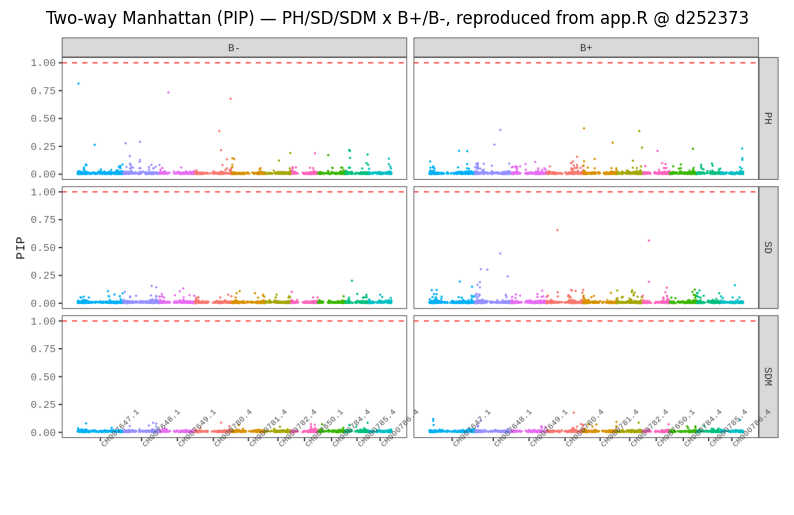

In [ ]:
# Display the produced two-way Manhattan plot (saved output of this run).
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("/content/two_way_manhattan.png")
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.imshow(img); ax.axis("off")
ax.set_title("Two-way Manhattan (PIP) — PH/SD/SDM x B+/B-, reproduced from app.R @ d252373")
plt.show()

## PheWAS plot (app.R server, tab 2)

**GUI-action → code mapping:** upload `PheWAS.csv`; default columns `names(df2)[7]`=type, `[1]`=phenotype, `[3]`=PIP, `[2]`=Marker_ID; point size 0.25; 2 columns; y-limits (−0.40, 1); threshold line at 1. Same two adaptations (PNG instead of `ggplotly()`; no seed needed here).

**日本語:** `app.R` の PheWAS 描画コード（211–218 行目）をそのままコピーして実行します。10 SNP ごとにパネル分割し、 phenotype を x 軸上に並べます。


In [ ]:
# Write and run the exact PheWAS pipeline from app.R.
import pathlib, subprocess, time
script = pathlib.Path("/content/phewas_pipeline.R")
script.write_text('# ---- Common setup (R) ----\nlibrary(ggplot2)\ncat("R:", R.version.string, "\\n")\ncat("ggplot2:", as.character(packageVersion("ggplot2")), "\\n")\n\n# Input: author-bundled PheWAS.csv (GWAS summary for 281 hyperspectral + 3\n# manual phenotypes, 10 SNPs). App default columns: names(df2)[7]=type,\n# [1]=phenotype, [3]=PIP, [2]=Marker_ID.\nphw <- read.csv("PheWAS.csv", header = TRUE, sep = ",", quote = \'"\')\ncat("rows:", nrow(phw), " columns:", paste(names(phw), collapse = ", "), "\\n")\ncat("unique phenotypes:", length(unique(phw[[1]])), " unique SNPs:", length(unique(phw[[2]])), "\\n")\n\n# ---- BEGIN EXACT COPY: app.R lines 211-218 ----\n# (input$pheno_cor=names[7], input$pheno_name=names[1], input$pvalue2=names[3],\n#  input$marker_ID2=names[2], input$point2=0.25, input$ncols=2,\n#  input$ylab2="PIP", input$xlab2=" ", input$ylim2=1, input$highlight2=TRUE,\n#  input$obs2=1: the app\'s defaults)\ndados2 <- phw[, c(names(phw)[7], names(phw)[1], names(phw)[3], names(phw)[2])]\ncolnames(dados2) <- c("Type", "Phenotype", "pvalue", "marker_ID2")\ndados2$Index <- as.numeric(as.factor(dados2$Phenotype))\nPhenoType <- unique(dados2$Type) ; breaks <- c()\nfor (i in 1:length(PhenoType)){breaks[i]<- median(dados2[dados2$Type==PhenoType[i], "Index"])}\n\ntemp_graph<- ggplot(dados2, aes(x = Index, y=pvalue, colour = Type, label = Phenotype)) +\n  geom_point(size = 0.25)+ theme_bw() +facet_wrap(~marker_ID2, ncol = 2)+\n  ylab("PIP")+ xlab(" ")+ ylim(-0.40, 1)+\n  scale_x_continuous(breaks=breaks,labels=unique(dados2$Type)) \n\ntemp_graph <- temp_graph + geom_hline(yintercept = 1, color="red", alpha = 0.75, size = 0.5, linetype = 2)\n# ---- END EXACT COPY ----\n\n# ADAPTATION: app wraps temp_graph in ggplotly(); headless we save PNG.\nggsave("phewas.png", temp_graph, width = 9, height = 7, dpi = 150)\ncat("saved phewas.png\\n")')
t0 = time.time()
r = subprocess.run(["Rscript", str(script)], capture_output=True, text=True, timeout=1800)
if r.returncode != 0:
    print(r.stdout, r.stderr)
    r.check_returncode()
print(r.stdout)
print(f"R elapsed: {time.time()-t0:.1f} s")

R: R version 4.6.1 (2026-06-24) 
ggplot2: 4.0.3 
rows: 2840  columns: Trait, Marker_ID, PIP, Wavelength, Chromosome, Position, Type 
unique phenotypes: 284  unique SNPs: 10 
saved phewas.png

R elapsed: 3.1 s


Display the produced PheWAS plot. **日本語:** 生成した PheWAS 図を表示します。

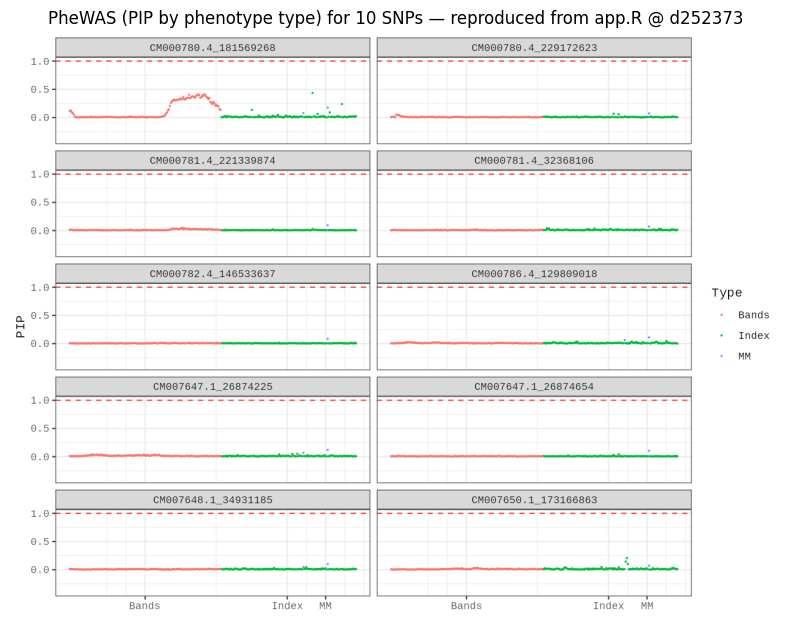

In [ ]:
# Display the produced PheWAS plot (saved output of this run).
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("/content/phewas.png")
fig, ax = plt.subplots(figsize=(10, 7.8))
ax.imshow(img); ax.axis("off")
ax.set_title("PheWAS (PIP by phenotype type) for 10 SNPs — reproduced from app.R @ d252373")
plt.show()

## Export results and interpretation

The two PNGs are the headless equivalents of the app's interactive panels. A small CSV export of the plotted (subsampled) Manhattan data is written for inspection in Colab.

**日本語:** 描画に使った Manhattan データ（サブサンプリング後）を CSV として保存し、必要ならダウンロードできます。


In [ ]:
# Export the subsampled Manhattan data (what the plot shows) and a row summary.
import subprocess, pathlib
summary_r = """
dados2 <- read.csv('Manhatan_full.csv')
set.seed(20261002)
d <- dados2[, c(names(dados2)[6], names(dados2)[3], names(dados2)[5], names(dados2)[1], names(dados2)[4], names(dados2)[2])]
colnames(d) <- c('Index','pvalue','Chromosome','trait1','trait2','Marker_ID')
d <- d[-sample(which(d$pvalue < 0.05), size = length(which(d$pvalue < 0.05))*0.85),]
write.csv(d, 'two_way_manhattan_data.csv', row.names = FALSE)
cat('exported rows:', nrow(d), '\\n')
"""
pathlib.Path("/content/export_manhattan.R").write_text(summary_r)
r = subprocess.run(["Rscript", "/content/export_manhattan.R"], capture_output=True, text=True, timeout=600)
if r.returncode != 0:
    print(r.stdout, r.stderr)
    r.check_returncode()
print(r.stdout)
import shutil; print("csv exists:", pathlib.Path("/content/two_way_manhattan_data.csv").exists())

exported rows: 12763 

csv exists: True


## Interpretation, differences from the paper, and validation record

**What was executed (this run):** the author's own R visualization code (`app.R` @ `d2523731d183c60f64e52d3534d7755d919bcbb1`) on the author-bundled result CSVs, downloaded from the pinned commit and verified by git blob SHA-1 and size. This reproduces the paper's *visualization* subsection (interactive Shiny exploration of the GWA results).

**Not reproduced / out of scope:**
- The Bayesian GWA analyses themselves (JWAS BayesC, 60,000 MCMC): raw genotypes, manual phenotypes, and hyperspectral reflectance data were not published; image-processing (Spectral Python) and index (hsdar) scripts were not released.
- The Shiny UI and `ggplotly()` interactivity (headless PNG instead); the app's unseeded random subsample is seeded here (set.seed(20261002)).

**Validation record:** executed on a fresh Google Colab CPU runtime; see the notebook report for date/hardware. Outputs are from this run only; a single-visualization demo does not verify dataset-level paper results.

**References:**
- Yassue et al. 2022, bioRxiv 10.1101/2022.08.11.503682 (v1); Plant Direct 2023, 10.1002/pld3.492.
- vt-ads/ShinyGWASPheWAS, commit d2523731d183c60f64e52d3534d7755d919bcbb1 (app.R, readme.md).

**日本語:** 本ノートブックは論文の可視化部分（Shiny アプリ）を著者コード・同梱 CSV で再現したものです。GWA 解析本体は生データ未公開のため対象外。UI・ggplotly による対話性は省略され、サブサンプリングにはシードを付与しています。
